# DeBERTa Reasoning Scorer for Cryptic Wordplay

This Colab notebook fine-tunes **`microsoft/deberta-v3-small`** as a verifier / reasoning scorer.

### Goal

For each candidate reasoning, the model receives:

\[
(\text{clue}, \text{answer}, \text{reasoning})
\]

and outputs a score:

\[
S(c,a,r) = P(\text{reasoning is correct}\mid c,a,r)
\]

A higher score means that DeBERTa believes the reasoning is more compatible with the clue and answer.

### Training signal

The Wordplay dataset contains human-written correct `wordplay` explanations, but no explicit negative reasonings.

We therefore build:

- **Positive**: the original `(clue, answer, wordplay)` → label `1`
- **Negative**: same `(clue, answer)` + a different clue's wordplay → label `0`

For harder negatives, the notebook preferentially chooses a wrong reasoning from an example with the **same answer pattern**.

> The resulting probability is a useful ranking score, but it should not automatically be interpreted as a perfectly calibrated probability of correctness.

## 1. Install dependencies

In Colab, first select **Runtime → Change runtime type → GPU**.

In [51]:
!pip install -q -U transformers datasets accelerate sentencepiece scikit-learn

## 2. Imports and configuration

In [52]:
import os
import re
import random
import inspect

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset, Dataset
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed,
)

SEED = 42
MODEL_NAME = "microsoft/deberta-v3-small"
MAX_LENGTH = 256

NUM_EPOCHS = 3
LEARNING_RATE = 2e-5
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
WEIGHT_DECAY = 0.01

set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


## 3. Load the Wordplay dataset from GitHub

The public sample in `mdda/cryptic-wordplay` contains `train` and `val` JSONL files.
Each item includes fields such as `clue`, `answer`, `pattern`, and `wordplay`.

In [27]:
BASE_URL = "https://raw.githubusercontent.com/mdda/cryptic-wordplay/main/prebuilt"

data_files = {
    "train": f"{BASE_URL}/sample_teacow_train.jsonl",
    "validation": f"{BASE_URL}/sample_teacow_val.jsonl",
}

raw_dataset = load_dataset("json", data_files=data_files)

print(raw_dataset)
print("\nExample:")
print(raw_dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['ad', 'answer', 'clue', 'num', 'pattern', 'wordplay', 'is_quick', 'publication', 'setter', 'author', 'comment'],
        num_rows: 5412
    })
    validation: Dataset({
        features: ['ad', 'answer', 'clue', 'num', 'pattern', 'wordplay', 'is_quick', 'publication', 'setter', 'author', 'comment'],
        num_rows: 300
    })
})

Example:
{'ad': 'A', 'answer': 'SEDATE', 'clue': '{Composed} , lawyer heading for tribunal in diocese', 'num': 1, 'pattern': '6', 'wordplay': 'DA (lawyer) + T[ribunal] in SEE (diocese)', 'is_quick': False, 'publication': 'financial-times', 'setter': 'falcon', 'author': 'teacow', 'comment': None}


## 4. Basic cleaning and sanity checks

In [28]:
def is_usable(example):
    required = ["clue", "answer", "wordplay", "pattern"]
    for key in required:
        value = example.get(key)
        if value is None:
            return False
        if not str(value).strip():
            return False
    return True


raw_dataset = raw_dataset.filter(is_usable)

print("Train examples:", len(raw_dataset["train"]))
print("Validation examples:", len(raw_dataset["validation"]))

print("\nColumns:")
print(raw_dataset["train"].column_names)

Train examples: 5412
Validation examples: 300

Columns:
['ad', 'answer', 'clue', 'num', 'pattern', 'wordplay', 'is_quick', 'publication', 'setter', 'author', 'comment']


In [29]:
def clean_clue(clue):
    # The dataset marks the definition span with {...}.
    # Remove the braces so the scorer cannot exploit an annotation
    # that would normally be unavailable at inference time.
    return str(clue).replace("{", "").replace("}", "")


for i in range(3):
    ex = raw_dataset["train"][i]
    print("Original:", ex["clue"])
    print("Clean:   ", clean_clue(ex["clue"]))
    print("Answer:  ", ex["answer"])
    print("Wordplay:", ex["wordplay"])
    print("-" * 100)

Original: {Composed} , lawyer heading for tribunal in diocese
Clean:    Composed , lawyer heading for tribunal in diocese
Answer:   SEDATE
Wordplay: DA (lawyer) + T[ribunal] in SEE (diocese)
----------------------------------------------------------------------------------------------------
Original: A worried couple endlessly ringing about {a place in Mexico}
Clean:    A worried couple endlessly ringing about a place in Mexico
Answer:   ACAPULCO
Wordplay: A + *(COUPL[E]) (*worried) ringing (around) CA (about, circa )
----------------------------------------------------------------------------------------------------
Original: {Showing intelligence} by keeping control in the auditorium
Clean:    Showing intelligence by keeping control in the auditorium
Answer:   BRAINY
Wordplay: BY around (keeping) RAIN (control = “rein” – sounds like, in the auditorium)
----------------------------------------------------------------------------------------------------


## 5. Build positive and negative reasoning examples

Each original item produces one pair:

- label `1`: correct reasoning
- label `0`: incorrect reasoning

The wrong reasoning is preferably taken from another clue with the same `pattern`.
This makes the negative less trivial than completely random text.

`pair_id` is kept only for later ranking evaluation.

In [30]:
def create_scoring_dataset(split, seed=42, shuffle=True):
    rng = random.Random(seed)
    examples = list(split)

    by_pattern = {}
    for i, ex in enumerate(examples):
        pattern = str(ex["pattern"])
        by_pattern.setdefault(pattern, []).append(i)

    rows = []

    for i, ex in enumerate(examples):
        clue = clean_clue(ex["clue"])
        answer = str(ex["answer"]).strip()
        correct_reasoning = str(ex["wordplay"]).strip()
        pattern = str(ex["pattern"])

        rows.append({
            "pair_id": i,
            "clue": clue,
            "answer": answer,
            "reasoning": correct_reasoning,
            "labels": 1,
        })

        same_pattern_candidates = [
            j for j in by_pattern.get(pattern, [])
            if (
                j != i
                and str(examples[j]["wordplay"]).strip() != correct_reasoning
                and str(examples[j]["answer"]).strip() != answer
            )
        ]

        if same_pattern_candidates:
            negative_idx = rng.choice(same_pattern_candidates)
        else:
            fallback = [
                j for j in range(len(examples))
                if (
                    j != i
                    and str(examples[j]["wordplay"]).strip() != correct_reasoning
                )
            ]
            negative_idx = rng.choice(fallback)

        wrong_reasoning = str(examples[negative_idx]["wordplay"]).strip()

        rows.append({
            "pair_id": i,
            "clue": clue,
            "answer": answer,
            "reasoning": wrong_reasoning,
            "labels": 0,
        })

    if shuffle:
        rng.shuffle(rows)

    return Dataset.from_list(rows)


train_scoring = create_scoring_dataset(
    raw_dataset["train"],
    seed=SEED,
    shuffle=True,
)

val_scoring = create_scoring_dataset(
    raw_dataset["validation"],
    seed=SEED + 1,
    shuffle=True,
)

print(train_scoring)
print(val_scoring)

train_labels = np.array(train_scoring["labels"])
val_labels = np.array(val_scoring["labels"])

print("\nTrain positive fraction:", train_labels.mean())
print("Validation positive fraction:", val_labels.mean())

Dataset({
    features: ['pair_id', 'clue', 'answer', 'reasoning', 'labels'],
    num_rows: 10824
})
Dataset({
    features: ['pair_id', 'clue', 'answer', 'reasoning', 'labels'],
    num_rows: 600
})

Train positive fraction: 0.5
Validation positive fraction: 0.5


In [31]:
positive = next(x for x in train_scoring if x["labels"] == 1)
negative = next(x for x in train_scoring if x["labels"] == 0)

for name, ex in [("POSITIVE", positive), ("NEGATIVE", negative)]:
    print("\n" + "=" * 100)
    print(name)
    print("Clue:     ", ex["clue"])
    print("Answer:   ", ex["answer"])
    print("Reasoning:", ex["reasoning"])
    print("Label:    ", ex["labels"])


POSITIVE
Clue:      Stone wall essentially needing work
Answer:    OPAL
Reasoning: [W]AL[l] (essentially) needing OP (work)
Label:     1

NEGATIVE
Clue:      No, X is. Pay attention!
Answer:    LISTEN
Reasoning: [pr]EDICTS (forecasts, to remove PR (spin))
Label:     0


## 6. Format the model input

We explicitly identify each component:

```text
CLUE: ...
ANSWER: ...
REASONING: ...
```

DeBERTa then performs binary sequence classification over the entire input.

In [32]:
def format_input(example):
    return (
        f"CLUE: {example['clue']}\n"
        f"ANSWER: {example['answer']}\n"
        f"REASONING: {example['reasoning']}"
    )


print(format_input(train_scoring[0]))

CLUE: No, X is. Pay attention!
ANSWER: LISTEN
REASONING: [pr]EDICTS (forecasts, to remove PR (spin))


## 7. Load DeBERTa from Hugging Face

In [33]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={
        0: "INCORRECT",
        1: "CORRECT",
    },
    label2id={
        "INCORRECT": 0,
        "CORRECT": 1,
    },
)

model.to(device)

print("Loaded:", MODEL_NAME)
print("Number of labels:", model.config.num_labels)

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifie

Loaded: microsoft/deberta-v3-small
Number of labels: 2


You may see a warning that the classification head was newly initialized.
That is expected: the pretrained DeBERTa encoder is loaded from Hugging Face,
while the final binary classification layer must be learned on this task.

## 8. Tokenize the datasets

In [34]:
def tokenize_function(example):
    text = format_input(example)

    return tokenizer(
        text,
        truncation=True,
        max_length=MAX_LENGTH,
    )


tokenized_train = train_scoring.map(
    tokenize_function,
    remove_columns=["pair_id", "clue", "answer", "reasoning"],
)

tokenized_val = val_scoring.map(
    tokenize_function,
    remove_columns=["pair_id", "clue", "answer", "reasoning"],
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(tokenized_train)
print("\nTokenized example:")
print(tokenized_train[0])

Map:   0%|          | 0/10824 [00:00<?, ? examples/s]

Map:   0%|          | 0/600 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 10824
})

Tokenized example:
{'labels': 0, 'input_ids': [1, 15591, 26504, 294, 585, 261, 1477, 269, 260, 5989, 1251, 300, 37094, 294, 66034, 70301, 4479, 294, 647, 14597, 592, 79750, 78319, 287, 86679, 268, 261, 264, 1963, 6181, 287, 26910, 285, 285, 2], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


## 9. Metrics

In [35]:
def softmax_np(logits):
    shifted = logits - np.max(logits, axis=-1, keepdims=True)
    exp = np.exp(shifted)
    return exp / np.sum(exp, axis=-1, keepdims=True)


def compute_metrics(eval_pred):
    logits, labels = eval_pred

    if isinstance(logits, tuple):
        logits = logits[0]

    probs = softmax_np(logits)
    predictions = np.argmax(probs, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        pos_label=1,
        zero_division=0,
    )

    try:
        auc = roc_auc_score(labels, probs[:, 1])
    except ValueError:
        auc = float("nan")

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
    }

## 10. Training arguments

The code below handles both newer Transformers versions that use
`eval_strategy` and older versions that use `evaluation_strategy`.

In [36]:
training_kwargs = dict(
    output_dir="/content/deberta-wordplay-reasoning-scorer",
    learning_rate=1e-6, # Changed from 2e-5
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    weight_decay=WEIGHT_DECAY,
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="auc",
    greater_is_better=True,
    save_total_limit=2,
    fp16=False, # Changed from torch.cuda.is_available() to False
    report_to="none",
    seed=SEED,
)

signature = inspect.signature(TrainingArguments.__init__)

if "eval_strategy" in signature.parameters:
    training_kwargs["eval_strategy"] = "epoch"
else:
    training_kwargs["evaluation_strategy"] = "epoch"

training_args = TrainingArguments(**training_kwargs)

print("Training arguments ready.")

Training arguments ready.


## 11. Create the Hugging Face Trainer

In [37]:
trainer_kwargs = dict(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer_signature = inspect.signature(Trainer.__init__)

if "processing_class" in trainer_signature.parameters:
    trainer_kwargs["processing_class"] = tokenizer
else:
    trainer_kwargs["tokenizer"] = tokenizer

trainer = Trainer(**trainer_kwargs)

print("Trainer ready.")

Trainer ready.


## 12. Fine-tune DeBERTa

In [38]:
print(f"TrainingArguments fp16 setting: {training_args.fp16}")
train_result = trainer.train()
train_result

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


TrainingArguments fp16 setting: False


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auc
1,0.263452,0.193477,0.931667,0.893617,0.980000,0.934817,0.984200
2,0.185707,0.150337,0.950000,0.972028,0.926667,0.948805,0.991250
3,0.097363,0.178215,0.945000,0.937705,0.953333,0.945455,0.992122


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2031, training_loss=0.2612448442985952, metrics={'train_runtime': 168.9072, 'train_samples_per_second': 192.248, 'train_steps_per_second': 12.024, 'total_flos': 407436625487712.0, 'train_loss': 0.2612448442985952, 'epoch': 3.0})

## 13. Validation metrics

In [39]:
val_metrics = trainer.evaluate()

print("Validation results")
print("-" * 60)

for key, value in val_metrics.items():
    if isinstance(value, float):
        print(f"{key:25s}: {value:.4f}")
    else:
        print(f"{key:25s}: {value}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Auc
0.097363,0.178215,3,0.945000,0.937705,0.953333,0.945455,0.992122


Validation results
------------------------------------------------------------
eval_loss                : 0.1782
eval_accuracy            : 0.9450
eval_precision           : 0.9377
eval_recall              : 0.9533
eval_f1                  : 0.9455
eval_auc                 : 0.9921


## 14. Plot train / validation loss

This is useful for spotting overfitting.

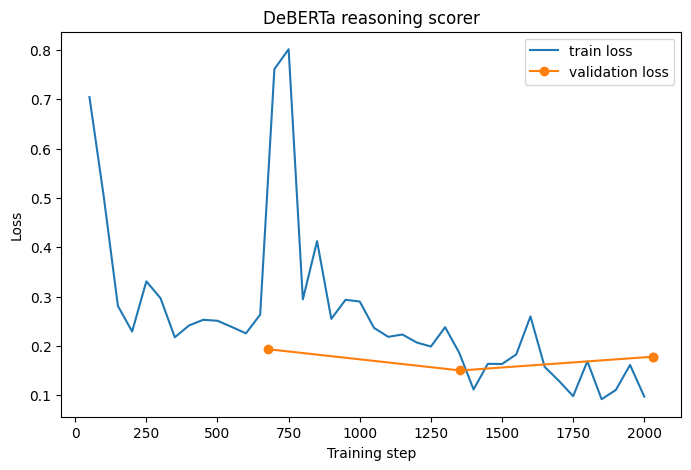

In [40]:
history = pd.DataFrame(trainer.state.log_history)

plt.figure(figsize=(8, 5))

if "loss" in history.columns:
    train_logs = history[history["loss"].notna()]
    if len(train_logs):
        plt.plot(train_logs["step"], train_logs["loss"], label="train loss")

if "eval_loss" in history.columns:
    eval_logs = history[history["eval_loss"].notna()]
    if len(eval_logs):
        plt.plot(
            eval_logs["step"],
            eval_logs["eval_loss"],
            marker="o",
            label="validation loss",
        )

plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("DeBERTa reasoning scorer")
plt.legend()
plt.show()

## 15. Single reasoning score

This is the main function you will use after training.

The returned value is:

\[
P(\text{CORRECT}\mid \text{clue},\text{answer},\text{reasoning})
\]

In [41]:
def reasoning_score(clue, answer, reasoning):
    model.eval()

    example = {
        "clue": clean_clue(clue),
        "answer": str(answer).strip(),
        "reasoning": str(reasoning).strip(),
    }

    text = format_input(example)

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        logits = model(**inputs).logits
        probabilities = torch.softmax(logits, dim=-1)

    return probabilities[0, 1].item()

### Try the scorer on a real validation example

In [42]:
example = raw_dataset["validation"][0]
wrong_example = raw_dataset["validation"][1]

clue = clean_clue(example["clue"])
answer = example["answer"]

correct_reasoning = example["wordplay"]
wrong_reasoning = wrong_example["wordplay"]

correct_score = reasoning_score(clue, answer, correct_reasoning)
wrong_score = reasoning_score(clue, answer, wrong_reasoning)

print("CLUE:  ", clue)
print("ANSWER:", answer)

print("\nCorrect reasoning:")
print(correct_reasoning)
print(f"Score: {correct_score:.4f}")

print("\nWrong reasoning:")
print(wrong_reasoning)
print(f"Score: {wrong_score:.4f}")

CLUE:   Fortune tellers scathing about Oscar
ANSWER: TAROT

Correct reasoning:
TART (scathing) about O[scar] (phonetic alphabet)
Score: 0.9810

Wrong reasoning:
*(GIVE GEAR) (*out)
Score: 0.0016


## 16. Score several candidate reasonings efficiently

Use this when another model generates several candidate chains of reasoning
and you want DeBERTa to rank them.

In [43]:
def reasoning_scores_batch(clues, answers, reasonings, batch_size=32):
    assert len(clues) == len(answers) == len(reasonings)

    model.eval()
    all_scores = []

    texts = [
        format_input({
            "clue": clean_clue(clue),
            "answer": str(answer).strip(),
            "reasoning": str(reasoning).strip(),
        })
        for clue, answer, reasoning in zip(clues, answers, reasonings)
    ]

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]

        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            logits = model(**inputs).logits
            probs = torch.softmax(logits, dim=-1)[:, 1]

        all_scores.extend(probs.cpu().tolist())

    return np.array(all_scores)


def rank_reasonings(clue, answer, candidate_reasonings):
    scores = reasoning_scores_batch(
        clues=[clue] * len(candidate_reasonings),
        answers=[answer] * len(candidate_reasonings),
        reasonings=candidate_reasonings,
    )

    ranked = sorted(
        zip(candidate_reasonings, scores),
        key=lambda x: x[1],
        reverse=True,
    )

    return ranked

In [44]:
ex = raw_dataset["validation"][0]

candidate_reasonings = [
    ex["wordplay"],
    raw_dataset["validation"][1]["wordplay"],
    raw_dataset["validation"][2]["wordplay"],
]

ranking = rank_reasonings(
    clue=clean_clue(ex["clue"]),
    answer=ex["answer"],
    candidate_reasonings=candidate_reasonings,
)

print("Clue:", clean_clue(ex["clue"]))
print("Answer:", ex["answer"])
print()

for rank, (reasoning, score) in enumerate(ranking, start=1):
    print(f"{rank}. score={score:.4f}")
    print(reasoning)
    print("-" * 80)

Clue: Fortune tellers scathing about Oscar
Answer: TAROT

1. score=0.9814
TART (scathing) about O[scar] (phonetic alphabet)
--------------------------------------------------------------------------------
2. score=0.0016
*(GIVE GEAR) (*out)
--------------------------------------------------------------------------------
3. score=0.0010
BAKER (cook) taking E (drug)
--------------------------------------------------------------------------------


## 17. Pairwise ranking accuracy

Classification accuracy asks whether each item crosses a fixed decision threshold.

For a scorer, a more direct question is:

> Given the same clue and answer, does DeBERTa assign a higher score to the
> correct reasoning than to the negative reasoning?

The metric below measures exactly that.

In [45]:
val_df = val_scoring.to_pandas()

val_df["score"] = reasoning_scores_batch(
    clues=val_df["clue"].tolist(),
    answers=val_df["answer"].tolist(),
    reasonings=val_df["reasoning"].tolist(),
    batch_size=EVAL_BATCH_SIZE,
)

pair_table = val_df.pivot_table(
    index="pair_id",
    columns="labels",
    values="score",
    aggfunc="first",
)

pair_table = pair_table.dropna(subset=[0, 1])

pairwise_accuracy = (pair_table[1] > pair_table[0]).mean()
mean_margin = (pair_table[1] - pair_table[0]).mean()

print(f"Pairwise ranking accuracy: {pairwise_accuracy:.4f}")
print(f"Mean positive-negative score margin: {mean_margin:.4f}")
print(f"Number of evaluated pairs: {len(pair_table)}")

Pairwise ranking accuracy: 0.9900
Mean positive-negative score margin: 0.8820
Number of evaluated pairs: 300


## 18. Inspect ranking mistakes

These are especially useful for improving the negative-generation strategy.

In [46]:
pair_table = pair_table.copy()
pair_table["margin"] = pair_table[1] - pair_table[0]

worst_pair_ids = (
    pair_table
    .sort_values("margin")
    .head(5)
    .index
    .tolist()
)

for pair_id in worst_pair_ids:
    pair_rows = val_df[val_df["pair_id"] == pair_id].sort_values(
        "labels",
        ascending=False,
    )

    print("=" * 110)

    for _, row in pair_rows.iterrows():
        kind = "TRUE" if row["labels"] == 1 else "NEGATIVE"

        print(f"\n{kind} | score={row['score']:.4f}")
        print("Clue:     ", row["clue"])
        print("Answer:   ", row["answer"])
        print("Reasoning:", row["reasoning"])


TRUE | score=0.0122
Clue:      High flier’s very low score on course
Answer:    ALBATROSS
Reasoning: Double Definition

NEGATIVE | score=0.6182
Clue:      High flier’s very low score on course
Answer:    ALBATROSS
Reasoning: (ODD AUSTEN)* (*novel)

TRUE | score=0.7324
Clue:      Fairly good way to rebuke
Answer:    MODERATE
Reasoning: Double Definition

NEGATIVE | score=0.7959
Clue:      Fairly good way to rebuke
Answer:    MODERATE
Reasoning: L (learner) + I G (one good) on H (hard) + TEST (exam)

TRUE | score=0.9751
Clue:      Murdoch could be a bit of a looker
Answer:    IRIS
Reasoning: Double Definition

NEGATIVE | score=0.9897
Clue:      Murdoch could be a bit of a looker
Answer:    IRIS
Reasoning: STUN< (stagger, back)

TRUE | score=0.0081
Clue:      Ball hit over the baseline probably not a winner
Answer:    LONG SHOT
Reasoning: Double Definition

NEGATIVE | score=0.0045
Clue:      Ball hit over the baseline probably not a winner
Answer:    LONG SHOT
Reasoning: (POSTED)* (*awfu

## 19. Save validation scores to CSV

In [47]:
VAL_SCORES_PATH = "/content/validation_reasoning_scores.csv"

val_df.to_csv(VAL_SCORES_PATH, index=False)

print("Saved:", VAL_SCORES_PATH)

Saved: /content/validation_reasoning_scores.csv


## 20. Save the fine-tuned model

In [48]:
SAVE_DIR = "/content/deberta-wordplay-reasoning-scorer-final"

trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print("Model saved to:", SAVE_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/deberta-wordplay-reasoning-scorer-final


### Optional: zip the model for download

In [49]:
!cd /content && zip -qr deberta-wordplay-reasoning-scorer-final.zip deberta-wordplay-reasoning-scorer-final

print("/content/deberta-wordplay-reasoning-scorer-final.zip")

/content/deberta-wordplay-reasoning-scorer-final.zip


## 21. Optional: copy the trained model to Google Drive

Run this only if you want the checkpoint to persist after the Colab session ends.

In [50]:
# from google.colab import drive
# import shutil
#
# drive.mount("/content/drive")
#
# DRIVE_SAVE_DIR = "/content/drive/MyDrive/deberta-wordplay-reasoning-scorer-final"
# shutil.copytree(SAVE_DIR, DRIVE_SAVE_DIR, dirs_exist_ok=True)
#
# print("Copied model to:", DRIVE_SAVE_DIR)

## Recommended next improvement

This notebook is a **baseline reasoning verifier**.

The positive examples are high quality because they come from the human `wordplay`
annotations. The main limitation is the negative examples: a reasoning from another
clue can sometimes be too easy to reject.

A stronger version should train on **hard negatives**, for example:

1. Reasonings generated by the model you actually plan to evaluate.
2. Nearly-correct reasonings with one incorrect decomposition or indicator.
3. Multiple candidate reasonings for the same clue/answer, ranked by correctness.
4. Pairwise or margin-ranking loss rather than only binary classification.

That setup would train DeBERTa to distinguish subtle reasoning errors rather than
merely unrelated explanations.